In [111]:
# Import libraries that will be needed for the lab
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image
import os, datetime

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.metrics import roc_curve, auc, confusion_matrix
from sklearn.cluster import KMeans

import tensorflow as tf
from keras import optimizers
from keras.models import Model
from keras.layers import Input, Dense, Dropout
from keras.utils import plot_model
%load_ext tensorboard

import pickle

import random
random.seed(123)

data_path = './data'

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


In [112]:
pct_anomalies = .01

filename = './preprocessed_data_full.pkl'
input_file = open(filename,'rb')
preprocessed_data = pickle.load(input_file)
input_file.close()

In [113]:
for key in preprocessed_data:
    print(key)

x_train
y_train
x_test
y_test
le


In [114]:
le = preprocessed_data['le']
x_train = preprocessed_data['x_train']
y_train = preprocessed_data['y_train']
x_test = preprocessed_data['x_test']
y_test = preprocessed_data['y_test']

In [115]:
# Normalize the testing and training data using the MinMaxScaler from the scikit learn package
scaler = MinMaxScaler()

# Make sure to only fit the scaler on the training data
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

# convert the data to FP32
x_train = x_train.astype(np.float32)
x_test = x_test.astype(np.float32)

In [116]:
input_dim = x_train.shape[1]

# model hyperparameters
batch_size = 512

latent_dim = 4

max_epochs = 10 

input_dim

111

In [117]:
# The encoder will consist of a number of dense layers that decrease in size 
# as we taper down towards the bottleneck of the network, the latent space
input_data = Input(shape=(input_dim,), name='encoder_input')

# hidden layers
encoder = Dense(96,activation='tanh', name='encoder_1')(input_data)
encoder = Dropout(.1)(encoder)
encoder = Dense(64,activation='tanh', name='encoder_2')(encoder)
encoder = Dropout(.1)(encoder)
encoder = Dense(48,activation='tanh', name='encoder_3')(encoder)
encoder = Dropout(.1)(encoder)
encoder = Dense(16,activation='tanh', name='encoder_4')(encoder)
encoder = Dropout(.1)(encoder)

# bottleneck layer
latent_encoding = Dense(latent_dim, activation='linear', name='latent_encoding')(encoder)

In [118]:
encoder_model = Model(input_data, latent_encoding)

encoder_model.summary()

Model: "functional_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder_input (InputLayer)      │ (None, 111)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_1 (Dense)               │ (None, 96)             │        10,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_48 (Dropout)            │ (None, 96)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_2 (Dense)               │ (None, 64)             │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_49 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_3 (Dense)               │ (None, 48)             │         3,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_50 (Dropout)            │ (None, 48)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_4 (Dense)               │ (None, 16)             │           784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_51 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent_encoding (Dense)         │ (None, 4)              │            68 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,932 (81.77 KB)

 Trainable params: 20,932 (81.77 KB)

 Non-trainable params: 0 (0.00 B)

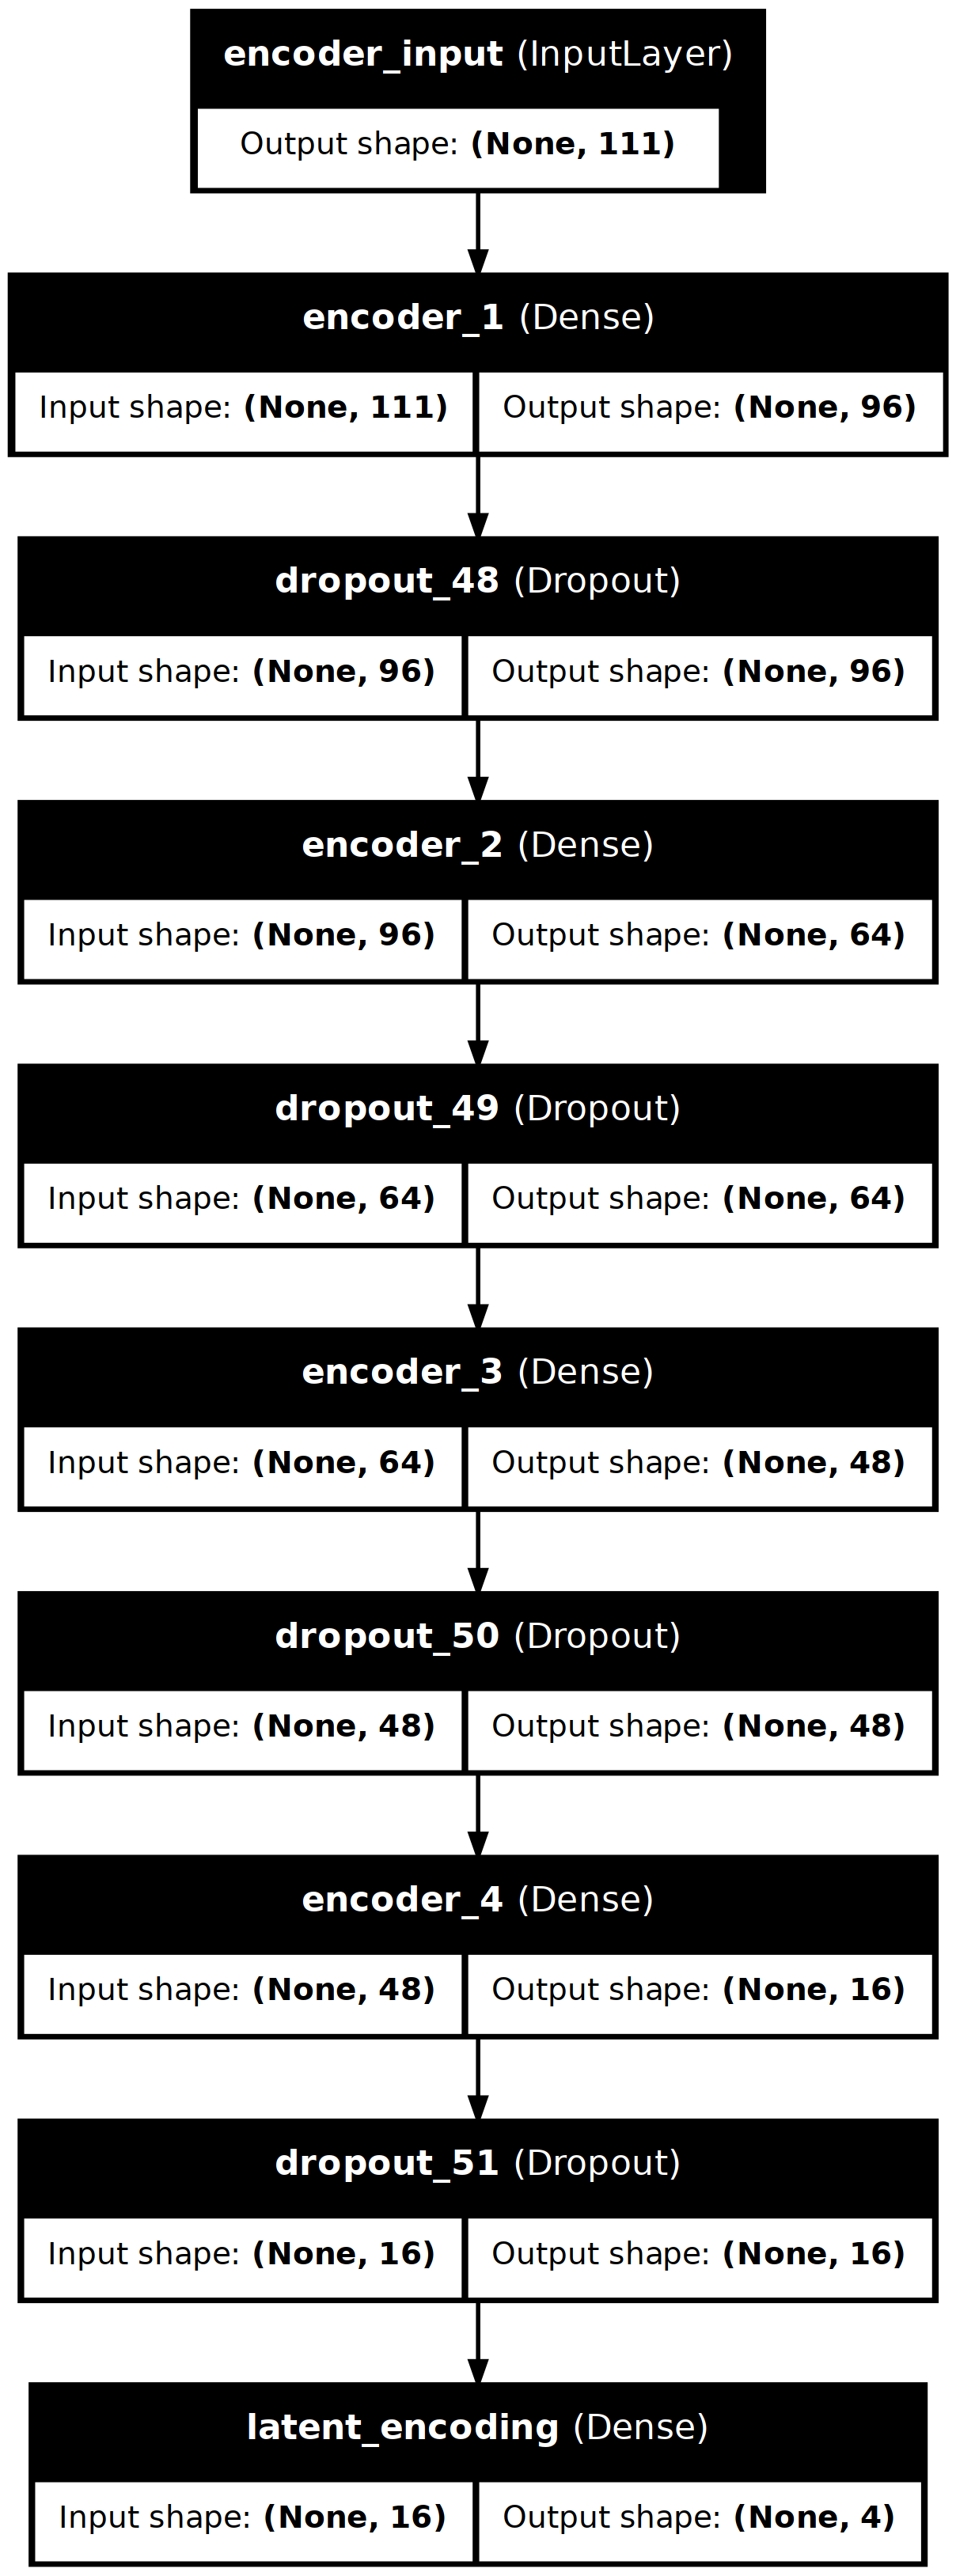

In [119]:
plot_model(
    encoder_model, 
    to_file='encoder_model.png', 
    show_shapes=True, 
    show_layer_names=True, 
    rankdir='TB' # TB for top to bottom, LR for left to right
)

Image(filename='encoder_model.png')

In [120]:
# The decoder network is a mirror image of the encoder network
decoder = Dense(16, activation='tanh', name='decoder_1')(latent_encoding)
decoder = Dropout(.1)(decoder)
decoder = Dense(48, activation='tanh', name='decoder_2')(decoder)
decoder = Dropout(.1)(decoder)
decoder = Dense(64, activation='tanh', name='decoder_3')(decoder)
decoder = Dropout(.1)(decoder)
decoder = Dense(96, activation='tanh', name='decoder_4')(decoder)
decoder = Dropout(.1)(decoder)

# The output is the same dimension as the input data we are reconstructing
reconstructed_data = Dense(input_dim, activation='linear', name='reconstructed_data')(decoder)

In [121]:
# The decoder network is a mirror image of the encoder network
decoder = Dense(16, activation='tanh', name='decoder_1')(latent_encoding)
decoder = Dropout(.1)(decoder)
decoder = Dense(32, activation='tanh', name='decoder_2')(decoder)
decoder = Dropout(.1)(decoder)
decoder = Dense(48, activation='tanh', name='decoder_3')(decoder)
decoder = Dropout(.1)(decoder)
decoder = Dense(64, activation='tanh', name='decoder_4')(decoder)
decoder = Dropout(.1)(decoder)

# The output is the same dimension as the input data we are reconstructing
reconstructed_data = Dense(input_dim, activation='linear', name='reconstructed_data')(decoder)


In [122]:
autoencoder_model = Model(input_data, reconstructed_data)

autoencoder_model.summary()

Model: "functional_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder_input (InputLayer)      │ (None, 111)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_1 (Dense)               │ (None, 96)             │        10,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_48 (Dropout)            │ (None, 96)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_2 (Dense)               │ (None, 64)             │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_49 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_3 (Dense)               │ (None, 48)             │         3,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_50 (Dropout)            │ (None, 48)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_4 (Dense)               │ (None, 16)             │           784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_51 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent_encoding (Dense)         │ (None, 4)              │            68 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_1 (Dense)               │ (None, 16)             │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_56 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_2 (Dense)               │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_57 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_3 (Dense)               │ (None, 48)             │         1,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_58 (Dropout)            │ (None, 48)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_4 (Dense)               │ (None, 64)             │         3,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_59 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reconstructed_data (Dense)      │ (None, 111)            │         7,215 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,491 (130.82 KB)

 Trainable params: 33,491 (130.82 KB)

 Non-trainable params: 0 (0.00 B)

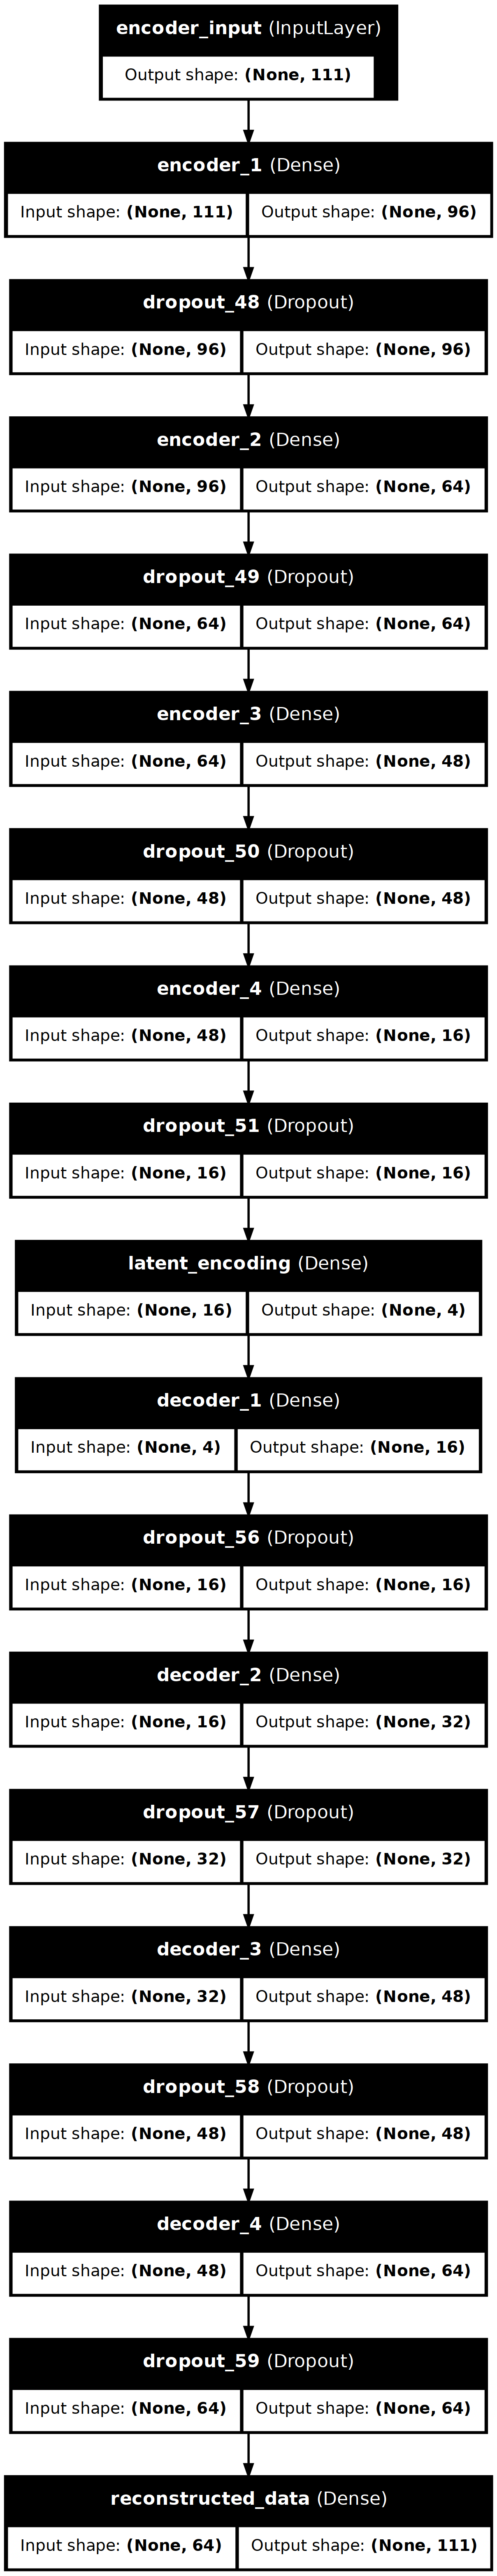

In [123]:
plot_model(
    autoencoder_model, 
    to_file='autoencoder_model.png', 
    show_shapes=True, 
    show_layer_names=True, 
    rankdir='TB' # TB for top to bottom, LR for left to right
)

Image(filename='autoencoder_model.png')

In [129]:
opt = optimizers.Adam(learning_rate=.00001)

autoencoder_model.compile(optimizer=opt, loss='mse', metrics=['accuracy'])

In [130]:
logdir = os.path.join("logs", datetime.datetime.now().strftime("%Y%m%d-%H%M%S"))
tensorboard_callback = tf.keras.callbacks.TensorBoard(logdir,profile_batch=0,update_freq='epoch',histogram_freq=1)

train_history = autoencoder_model.fit(x_train, x_train,
        shuffle=True,
        epochs=max_epochs,
        batch_size=512,
        validation_data=(x_test, x_test),
        callbacks=[tensorboard_callback])

2024-10-15 21:41:55.607226: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 327175164 exceeds 10% of free system memory.


Epoch 1/10
1440/1440 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.1585 - loss: 0.0073 - val_accuracy: 0.1608 - val_loss: 0.0049
Epoch 2/10
1440/1440 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.1587 - loss: 0.0071 - val_accuracy: 0.1593 - val_loss: 0.0049
Epoch 3/10
1440/1440 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.1592 - loss: 0.0069 - val_accuracy: 0.1626 - val_loss: 0.0049
Epoch 4/10
1440/1440 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.1585 - loss: 0.0068 - val_accuracy: 0.1606 - val_loss: 0.0049
Epoch 5/10
1440/1440 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.1595 - loss: 0.0067 - val_accuracy: 0.1567 - val_loss: 0.0048
Epoch 6/10
1440/1440 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.1593 - loss: 0.0066 - val_accuracy: 0.1563 - val_loss: 0.0048
Epoch 7/10
1440/1440 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.1591 - loss: 0.0065 - val_accuracy: 0.1511 - val_loss: 0.0048
Epoch 8/10
1440/1440 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.1587 - loss: 0.0064

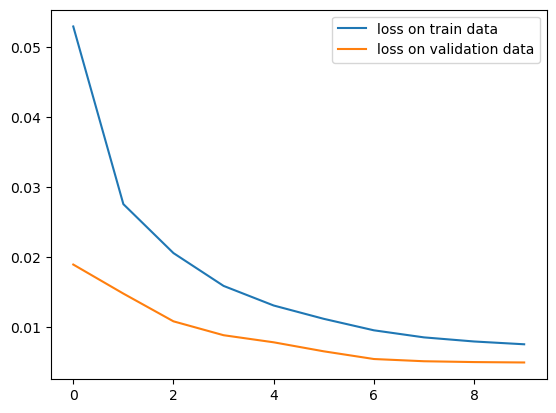

In [128]:
plt.plot(train_history.history['loss'])
plt.plot(train_history.history['val_loss'])
plt.legend(['loss on train data', 'loss on validation data'])

In [132]:
# Reconstruct the data using our trainined autoencoder model.
x_test_recon = autoencoder_model.predict(x_test)

# the reconstruction score is the mean of the reconstruction errors (relatively high scores are anomalous)
reconstruction_scores = np.mean((x_test - x_test_recon)**2, axis=1)

x_test_recon

7676/7676 ━━━━━━━━━━━━━━━━━━━━ 6s 821us/step


array([[ 8.84663314e-06, -1.19545730e-05, -8.41574278e-04, ...,
        -1.41835772e-05,  1.03609920e+00,  1.41022465e-05],
       [ 8.53938982e-05, -1.10004330e-05,  2.75985990e-03, ...,
        -1.63430814e-05,  9.39347982e-01,  9.08483344e-06],
       [ 7.38287345e-05, -1.16224401e-05, -8.98540020e-05, ...,
        -1.65326055e-05,  9.52784598e-01,  1.05736108e-05],
       ...,
       [ 3.22498381e-04,  2.01248331e-05,  6.95382506e-02, ...,
         6.90715387e-06,  9.62058127e-01, -1.17771415e-05],
       [ 3.42046842e-05, -1.15945004e-05, -3.21955746e-03, ...,
        -1.00908801e-05,  9.98847723e-01,  1.42219942e-05],
       [ 8.81627202e-05, -1.07565429e-05,  2.72735953e-04, ...,
        -1.61025673e-05,  9.45619702e-01,  1.00628386e-05]], dtype=float32)

In [133]:
# store the reconstruction data in a Pandas dataframe
anomaly_data = pd.DataFrame({'recon_score':reconstruction_scores})

# if our reconstruction scores our normally distributed we can use their statistics
anomaly_data.describe()

,recon_score
count,245627.000000
mean,0.004809
std,0.008161
min,0.000052
25%,0.001384
50%,0.002235
75%,0.004674
max,1.497985


<Axes: ylabel='Frequency'>

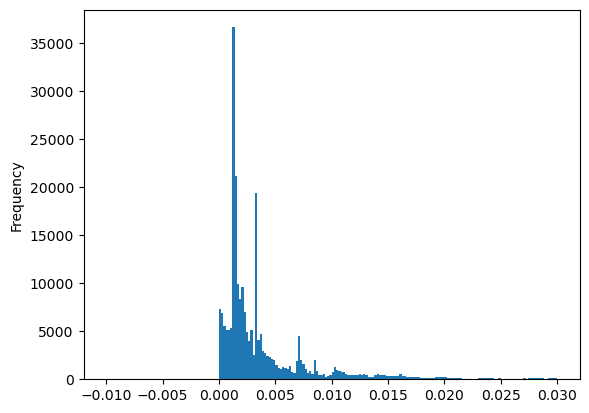

In [134]:
# plotting the density will give us an idea of how the reconstruction scores are distributed
plt.xlabel('Reconstruction Score')
anomaly_data['recon_score'].plot.hist(bins=200, range=[-.01, .03])

In [152]:
def convert_label_to_binary(label_encoder, labels):
    normal_idx = np.where(label_encoder.classes_ == 'normal.')[0][0]
    my_labels = labels.copy()
    my_labels[my_labels != normal_idx] = 1 
    my_labels[my_labels == normal_idx] = 0
    return my_labels

In [153]:
# convert our labels to binary
binary_labels = convert_label_to_binary(le, y_test)

# add the binary labels to our anomaly dataframe
anomaly_data['binary_labels'] = binary_labels

# let's check if the reconstruction statistics are different for labeled anomalies
anomaly_data.groupby(by='binary_labels').describe()

recon_score                                                    \
                    count      mean       std       min       25%       50%   
binary_labels                                                                 
0                243161.0  0.004307  0.006333  0.000052  0.001384  0.002204   
1                  2466.0  0.054360  0.014215  0.002523  0.047186  0.047186   

                                   
                    75%       max  
binary_labels                      
0              0.004521  1.497985  
1              0.047186  0.084132

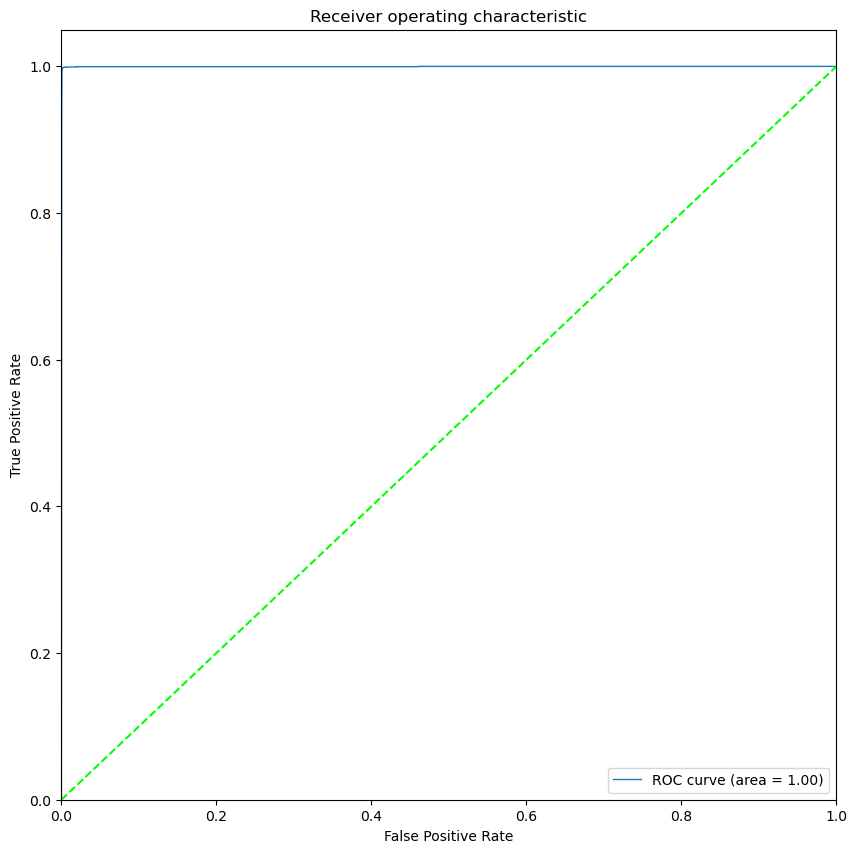

In [154]:
fpr, tpr, thresholds = roc_curve(binary_labels, reconstruction_scores)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(10,10))
plt.plot(fpr, tpr, lw=1, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='lime', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic')
plt.legend(loc="lower right")
plt.show()